# Decision Trees - TCGA Clinical Data - Classifying Cancer Stage

In [65]:
install.packages("rpart")
install.packages("rpart.plot")
install.packages("cvms")


The downloaded binary packages are in
	/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T//Rtmpyo4Rs2/downloaded_packages

The downloaded binary packages are in
	/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T//Rtmpyo4Rs2/downloaded_packages


also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘rbibutils’, ‘prodlim’, ‘numbers’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘Rcpp’, ‘RcppEigen’, ‘insight’, ‘bayestestR’, ‘datawizard’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘checkmate’, ‘groupdata2’, ‘lme4’, ‘MuMIn’, ‘parameters’, ‘plyr’, ‘pROC’, ‘rearrr’, ‘recipes’, ‘reformulas’





The downloaded binary packages are in
	/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T//Rtmpyo4Rs2/downloaded_packages


In [66]:
library(rpart)
library(rpart.plot)
library(dplyr)
library(tidyr)
library(cvms)
library(ggplot2)

In [29]:
clin_data <- read.csv("filtered_stages.csv")
head(clin_data)
colnames(clin_data)

,Stage,Diagnosis.Age,Aneuploidy.Score,Cancer.Type.Detailed,Fraction.Genome.Altered,Sex,Mutation.Count
,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<int>
1,STAGE I,61,19,Colon Adenocarcinoma,0.1127,Female,120
2,STAGE IIIB,67,13,Colon Adenocarcinoma,0.3130,Male,85
3,STAGE IIA,42,18,Mucinous Adenocarcinoma of the Colon and Rectum,0.2816,Female,120
4,STAGE IV,74,18,Colon Adenocarcinoma,0.4095,Male,176
5,STAGE IV,40,3,Colon Adenocarcinoma,0.0500,Female,1860
6,STAGE IIA,76,20,Colon Adenocarcinoma,0.4018,Male,113


[1] "Stage"                   "Diagnosis.Age"          
[3] "Aneuploidy.Score"        "Cancer.Type.Detailed"   
[5] "Fraction.Genome.Altered" "Sex"                    
[7] "Mutation.Count"

In [46]:
#train-test split - already performed in NB, so let's use the same data 
train_data <- read.csv("train_data_filtered.csv")
test_data <- read.csv("test_data_filtered.csv")

In [47]:
head(train_data)
head(test_data)



,Stage,Diagnosis.Age,Aneuploidy.Score,Cancer.Type.Detailed,Fraction.Genome.Altered,Sex,Mutation.Count
,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<int>
1,STAGE II,51,7,Rectal Adenocarcinoma,0.2911,Male,81
2,STAGE IIA,60,3,Colon Adenocarcinoma,0.0897,Male,1058
3,STAGE IIA,65,3,Rectal Adenocarcinoma,0.0548,Male,89
4,STAGE IIIB,68,19,Rectal Adenocarcinoma,0.4585,Male,NA
5,STAGE IV,45,24,Colon Adenocarcinoma,0.4529,Male,NA
6,STAGE IIA,84,7,Colon Adenocarcinoma,0.1088,Female,204


,Stage,Diagnosis.Age,Aneuploidy.Score,Cancer.Type.Detailed,Fraction.Genome.Altered,Sex,Mutation.Count
,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<int>
1,STAGE IIIB,67,13,Colon Adenocarcinoma,0.3130,Male,85
2,STAGE IV,74,18,Colon Adenocarcinoma,0.4095,Male,176
3,STAGE IIA,76,20,Colon Adenocarcinoma,0.4018,Male,113
4,STAGE IIIC,68,8,Colon Adenocarcinoma,NA,Female,116
5,STAGE IIA,73,13,Colon Adenocarcinoma,0.3353,Female,130
6,STAGE IV,57,20,Colon Adenocarcinoma,0.4112,Female,33


In [48]:
#confirm our classes stayed correct
print(sort(unique(train_data$Stage)))
print("")
print(sort(unique(test_data$Stage)))

 [1] "STAGE I"    "STAGE II"   "STAGE IIA"  "STAGE IIB"  "STAGE III" 
 [6] "STAGE IIIA" "STAGE IIIB" "STAGE IIIC" "STAGE IV"   "STAGE IVA" 
[1] ""
 [1] "STAGE I"    "STAGE II"   "STAGE IIA"  "STAGE IIB"  "STAGE III" 
 [6] "STAGE IIIA" "STAGE IIIB" "STAGE IIIC" "STAGE IV"   "STAGE IVA" 


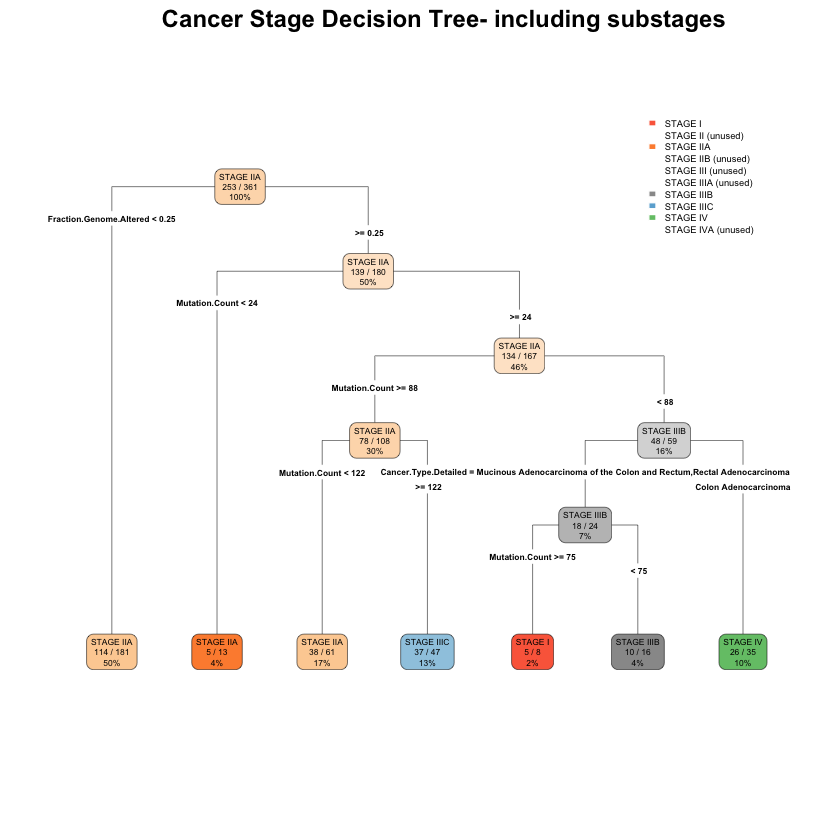

In [51]:

dec_tree <- rpart(Stage ~ . , data= train_data, method="class")
#display a plot with extra info
rpart.plot(dec_tree, type=4, extra=103)
title(main="Cancer Stage Decision Tree- including substages", line=3)

In [75]:
summary(dec_tree)

Call:
rpart(formula = Stage ~ ., data = train_data, method = "class")
  n= 361 

          CP nsplit rel error  xerror       xstd
1 0.01054018      0 1.0000000 1.00000 0.03438730
2 0.01000000      6 0.9288538 1.13834 0.03016363

Variable importance
         Mutation.Count Fraction.Genome.Altered        Aneuploidy.Score 
                     45                      22                      15 
   Cancer.Type.Detailed           Diagnosis.Age 
                     11                       8 

Node number 1: 361 observations,    complexity param=0.01054018
  predicted class=STAGE IIA   expected loss=0.700831  P(node) =1
    class counts:    64    21   108     5    13    11    46    36    37    20
   probabilities: 0.177 0.058 0.299 0.014 0.036 0.030 0.127 0.100 0.102 0.055 
  left son=2 (181 obs) right son=3 (180 obs)
  Primary splits:
      Fraction.Genome.Altered < 0.24555 to the left,  improve=4.415730, (5 missing)
      Mutation.Count          < 405.5   to the right, improve=2.784056, (

In [78]:
#accuracy calc
pred <- predict(dec_tree, clin_data, type="class")
conf_matrix <- table(Predicted=pred, Actual=clin_data$Stage)
accuracy <- sum(diag(conf_matrix)) / sum(conf_matrix)
accuracy

[1] 0.3184466

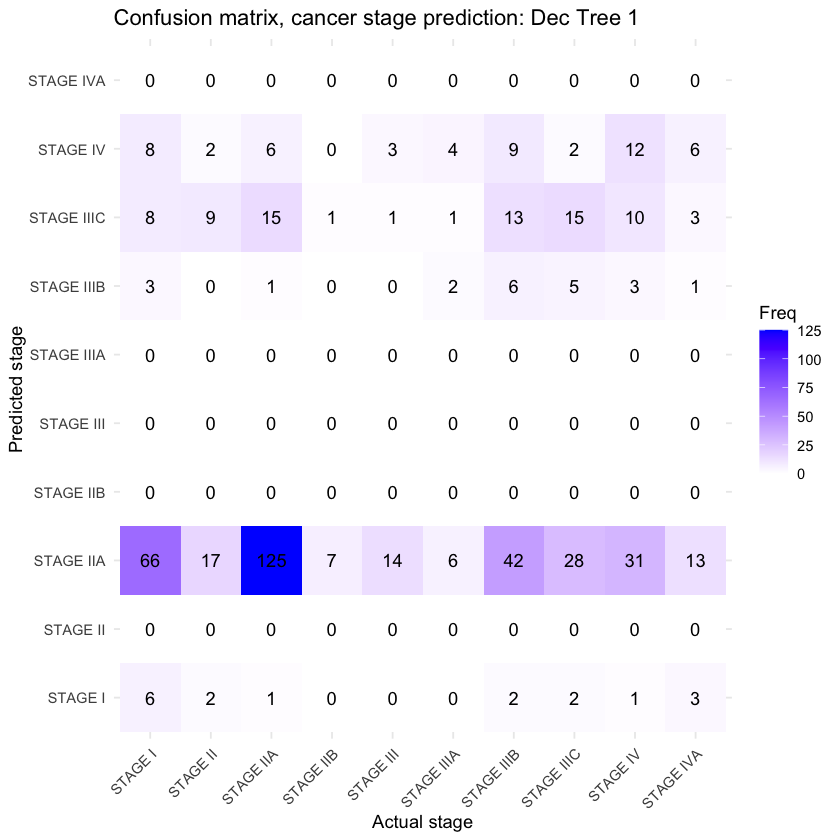

In [ ]:
#plot confusion matrix
ggplot(data= as.data.frame(conf_matrix), aes(x= Actual, y=Predicted)) +
  geom_tile(aes(fill = Freq)) +
  geom_text(aes(label= Freq)) +
  scale_fill_gradient(low= "white", high = "blue") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Confusion matrix, cancer stage prediction: Dec Tree 1", x= "Actual stage", y = "Predicted stage")

[1] 0.2727273

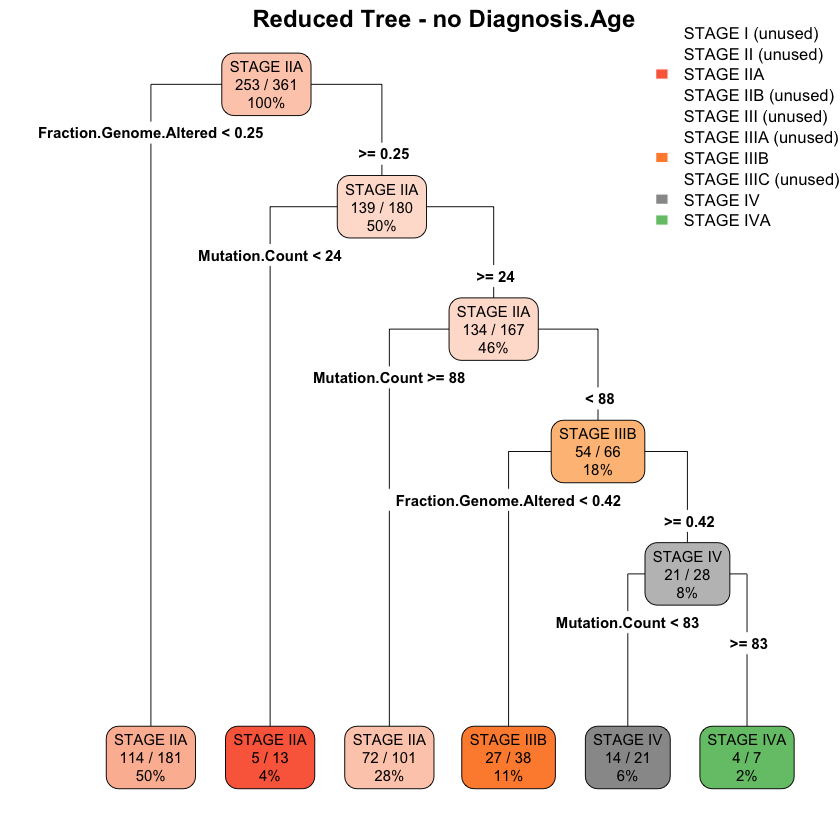

In [81]:
#generate a reduced tree to see if less is more
dec_tree_2 <- rpart(Stage ~ . -Diagnosis.Age, data = train_data, method = "class")
rpart.plot(dec_tree_2, type=4, extra=103)
title(main = "Reduced Tree - no Diagnosis.Age", line=3)

#accuracy
pred <- predict(dec_tree_2, test_data, type = "class")
conf_matrix_2 <- table(Predicted=pred, Actual=test_data$Stage)
accuracy <- sum(diag(conf_matrix_2)) / sum(conf_matrix_2)
accuracy

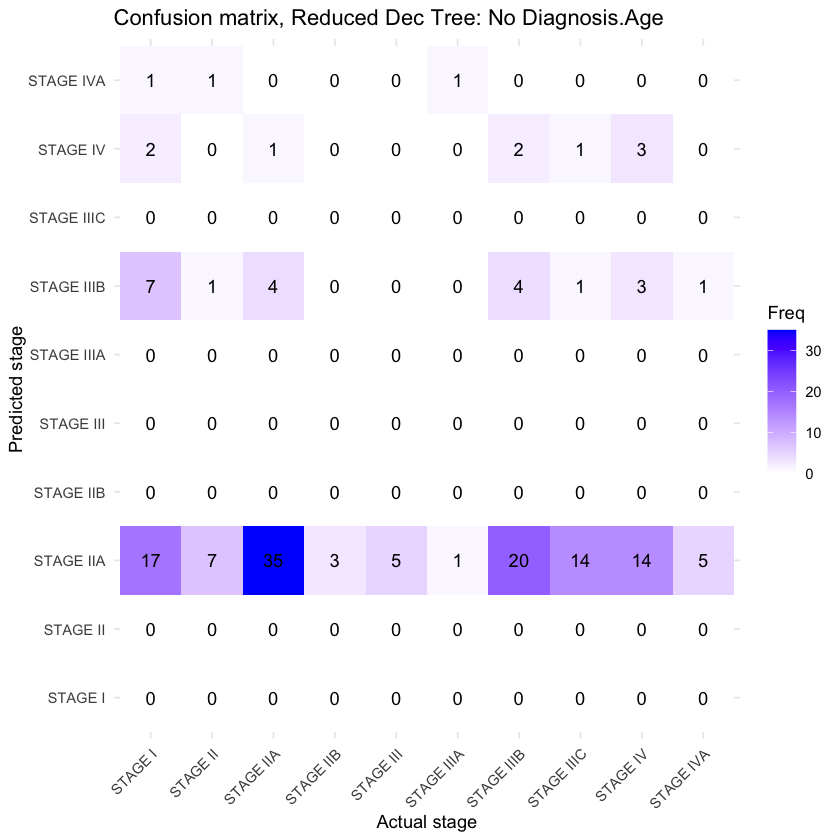

In [ ]:
#conf matrix plot
ggplot(data= as.data.frame(conf_matrix_2), aes(x= Actual, y=Predicted)) +
  geom_tile(aes(fill = Freq)) +
  geom_text(aes(label= Freq)) +
  scale_fill_gradient(low= "white", high = "blue") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Confusion matrix, Reduced Dec Tree: No Diagnosis.Age", x= "Actual stage", y = "Predicted stage")

[1] 0.2467532

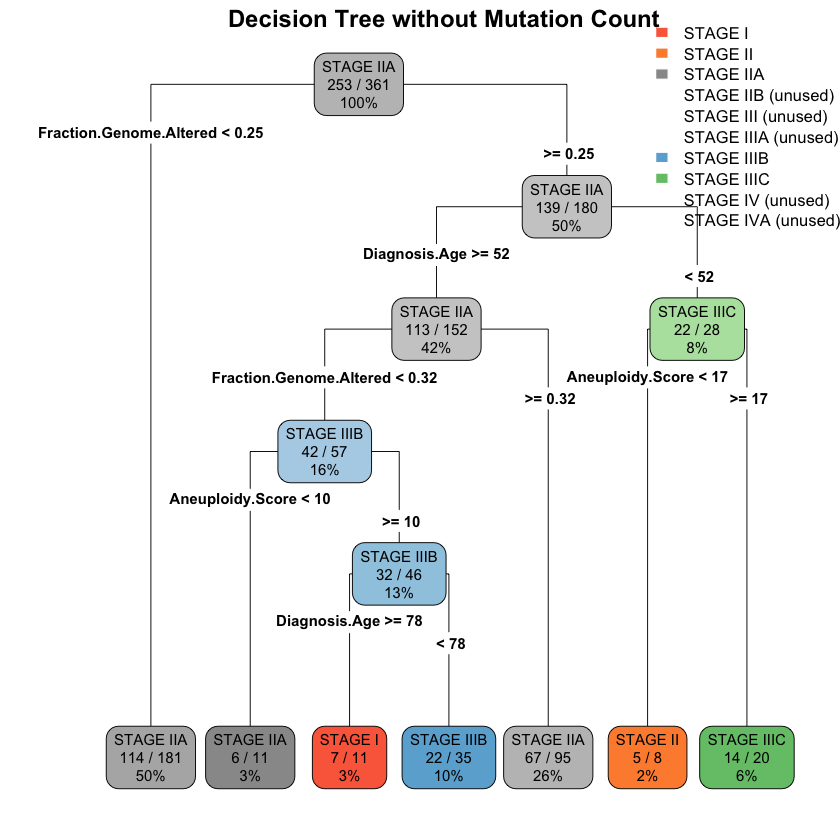

In [84]:
#adding back in Diagnosis.Age, but remove mutation count
dec_tree_3 <- rpart(Stage ~ . -Mutation.Count, data = train_data, method = "class")
rpart.plot(dec_tree_3, type=4, extra=103)
title(main = "Decision Tree without Mutation Count", line=3)

#accuracy
pred <- predict(dec_tree_3, test_data, type = "class")
conf_matrix_3 <- table(Predicted=pred, Actual=test_data$Stage)
accuracy <- sum(diag(conf_matrix_3)) / sum(conf_matrix_3)
accuracy

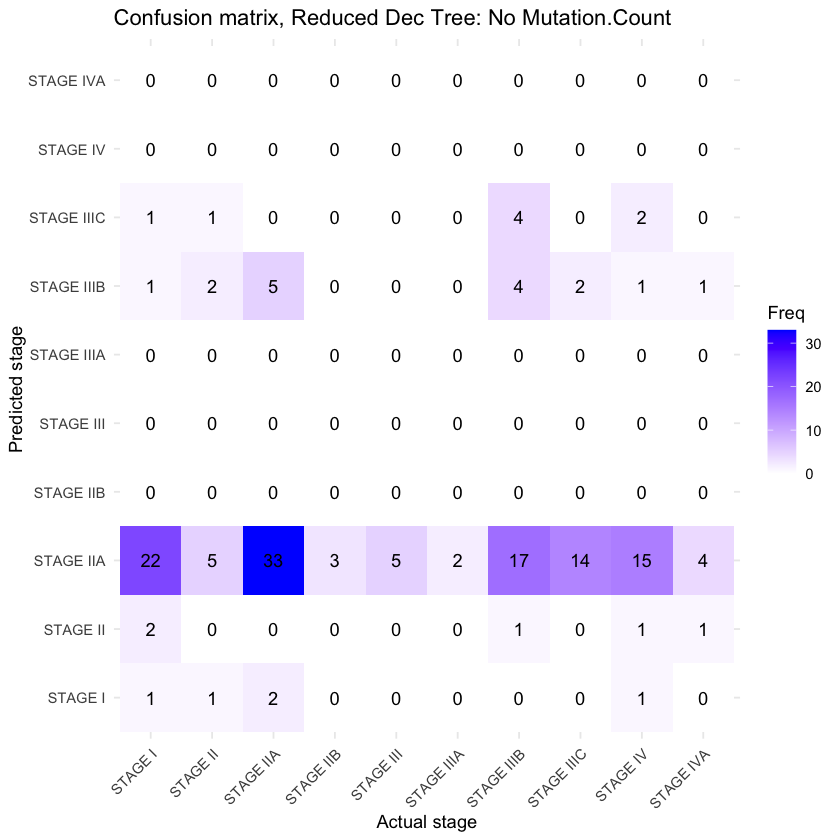

In [ ]:
#conf matrix plot
ggplot(data= as.data.frame(conf_matrix_3), aes(x= Actual, y=Predicted)) +
  geom_tile(aes(fill = Freq)) +
  geom_text(aes(label= Freq)) +
  scale_fill_gradient(low= "white", high = "blue") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Confusion matrix, Reduced Dec Tree: No Mutation.Count", x= "Actual stage", y = "Predicted stage")

In [57]:
#add a column that just keeps STAGE I, II, III, or IV, not the subtypes A and B
clin_data$Stage_Simple <- gsub("A|B|C|D", "", clin_data$Stage)
#drop the original Stage column
clin_data_simplified <- clin_data %>% select(-Stage)
train_data_simplified <- clin_data_simplified[train_index, ]
test_data_simplified <- clin_data_simplified[-train_index, ]



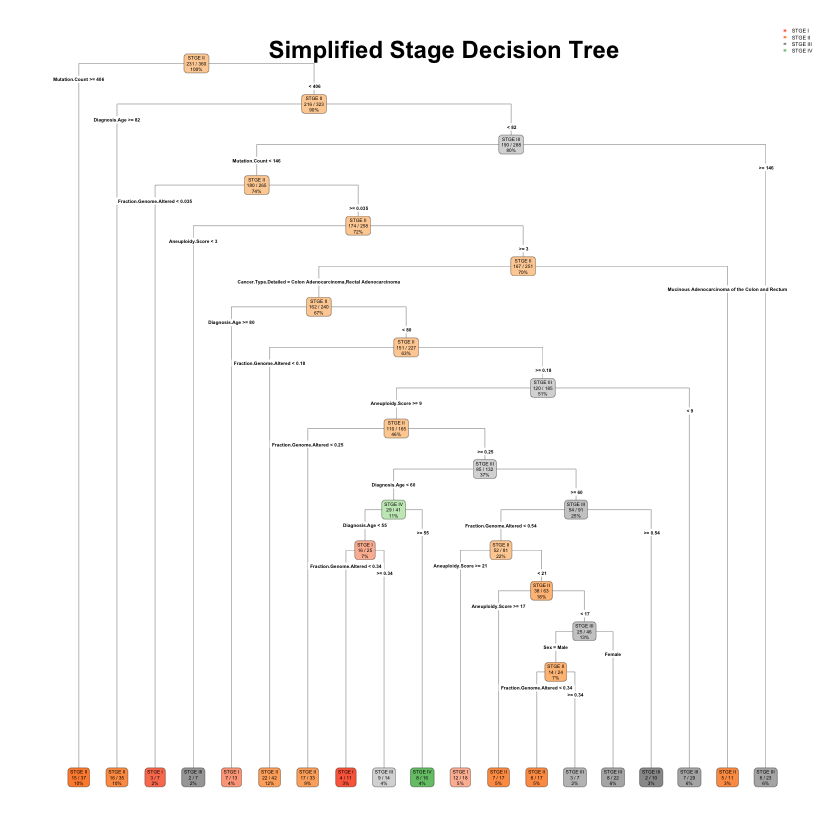

In [62]:
dec_tree_simplified <- rpart(Stage_Simple ~ . , data= train_data_simplified, method="class")
par(xpd=NA)
rpart.plot(dec_tree_simplified, type=4, extra=103, legend.x="topright")
#add title to the plot
title(main="Simplified Stage Decision Tree")

In [87]:
#predict
predictions_simplified <- predict(dec_tree_simplified, test_data_simplified, type = "class")
conf_matrix_simplified <- table(Predicted = predictions_simplified, Actual = test_data_simplified$Stage_Simple)
print(conf_matrix_simplified)

#accuracy
accuracy_simplified <- sum(diag(conf_matrix_simplified)) / sum(conf_matrix_simplified)
accuracy_simplified

          Actual
Predicted  STGE I STGE II STGE III STGE IV
  STGE I        2       4       10       4
  STGE II      11      32       21       5
  STGE III     14      17       12      13
  STGE IV       0       4        3       3


[1] 0.316129

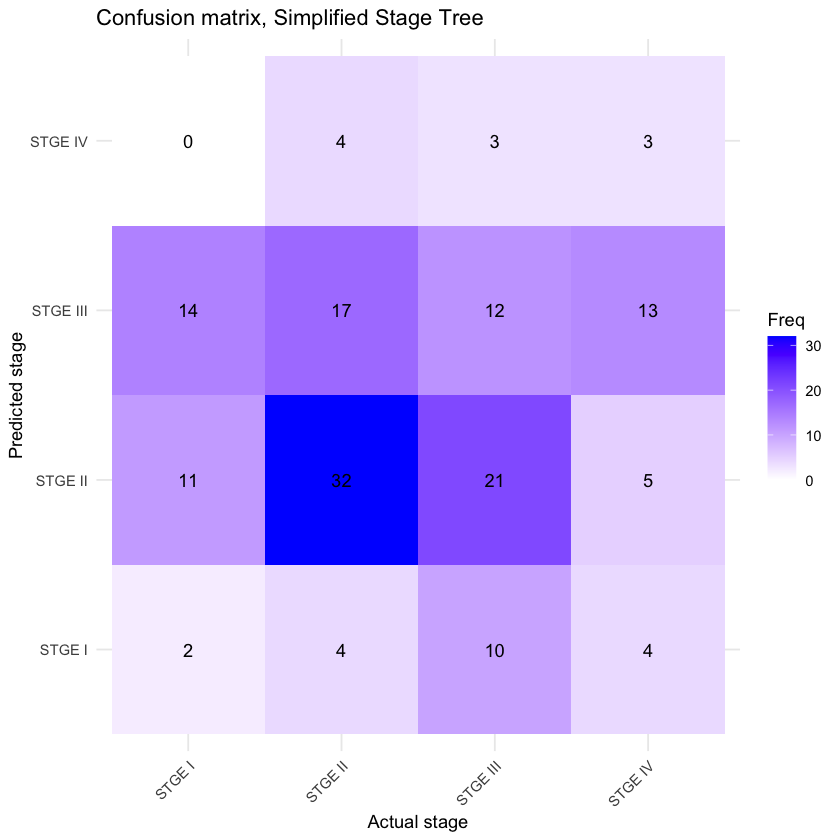

In [88]:
ggplot(data= as.data.frame(conf_matrix_simplified), aes(x= Actual, y=Predicted)) +
  geom_tile(aes(fill = Freq)) +
  geom_text(aes(label= Freq)) +
  scale_fill_gradient(low= "white", high = "blue") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Confusion matrix, Simplified Stage Tree", x= "Actual stage", y = "Predicted stage")

ERROR: Error in IRkernel::main(): 1 assertions failed:
 * Variable 'conf_matrix': Must be of type 'data.frame', not 'table'.
